In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [11]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from timm.utils import AverageMeter
from src.config import get_config
from src.models import build_model

In [13]:
CHEXPERT_LABELS = [
    "No Finding",
    "Enlarged Cardiomediastinum",
    "Cardiomegaly",
    "Lung Opacity",
    "Lung Lesion",
    "Edema",
    "Consolidation",
    "Pneumonia",
    "Atelectasis",
    "Pneumothorax",
    "Pleural Effusion",
    "Pleural Other",
    "Fracture",
    "Support Devices",
]

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Args:
    def __init__(self):
        self.cfg = "../configs/simmim_finetune__vit_base__img224__100ep_ablation.yaml" # Change to config you want to use
        self.opts = None
        self.batch_size = None
        self.data_path = None
        self.resume = None
        self.accumulation_steps = None
        self.use_checkpoint = False
        self.amp_opt_level = "O0"
        self.output = "output"
        self.tag = None
        self.local_rank = 0
        self.pretrained = None
        self.eval = False
        self.throughput = False
args = Args()
config = get_config(args)

config.defrost()
config.MODEL.NUM_CLASSES = 14
config.freeze()

model = build_model(config, is_pretrain=False)
ckpt_path = "../simmim_checkpoints/simmim_finetune/ckpt_epoch_99.pth" # change to model weights you want to use 
ckpt = torch.load(ckpt_path, map_location="cpu")

dictt = ckpt["model"]
new_dict = {}
for k, v in dictt.items():
    new_k = k.replace("module.","")
    new_dict[new_k] = v

model.load_state_dict(new_dict, strict=False)
model.eval()
print("Model loaded")


Configuration file loaded at ../configs ../configs/simmim_finetune__vit_base__img224__100ep_ablation.yaml
Model loaded


In [16]:
CHEXPERT_MEAN = [0.533430]
CHEXPERT_STD = [0.283167]

transform = transforms.Compose([
    transforms.Resize(config.DATA.IMG_SIZE),
    transforms.CenterCrop(config.DATA.IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = CHEXPERT_MEAN,
        std = CHEXPERT_STD
    ),
])

(np.float64(-0.5), np.float64(2443.5), np.float64(2154.5), np.float64(-0.5))

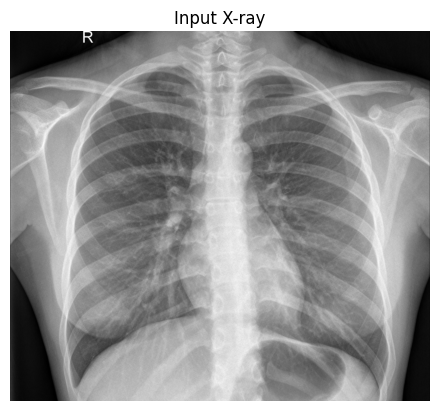

In [ ]:
image_path = "./demo_xrays/normal/normal_1.jpeg" # change to image you want to run the inference on
image = Image.open(image_path).convert("L")

plt.imshow(image, cmap="gray")
plt.title("Input X-ray")
plt.axis("off")

In [ ]:
input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.sigmoid(outputs).cpu().numpy()[0]

threshold = 0.5

print("Predictions:\n")
for i, prob in enumerate(probs):
    label = CHEXPERT_LABELS[i]
    pred = "Positive" if prob >= threshold else "Negative"
    print(f"{label:20s} {prob:.3f} {pred}")


Predictions:

No Finding           0.076 Negative
Enlarged Cardiomediastinum 0.048 Negative
Cardiomegaly         0.112 Negative
Lung Opacity         0.489 Negative
Lung Lesion          0.043 Negative
Edema                0.198 Negative
Consolidation        0.066 Negative
Pneumonia            0.027 Negative
Atelectasis          0.137 Negative
Pneumothorax         0.103 Negative
Pleural Effusion     0.389 Negative
Pleural Other        0.017 Negative
Fracture             0.044 Negative
Support Devices      0.542 Positive


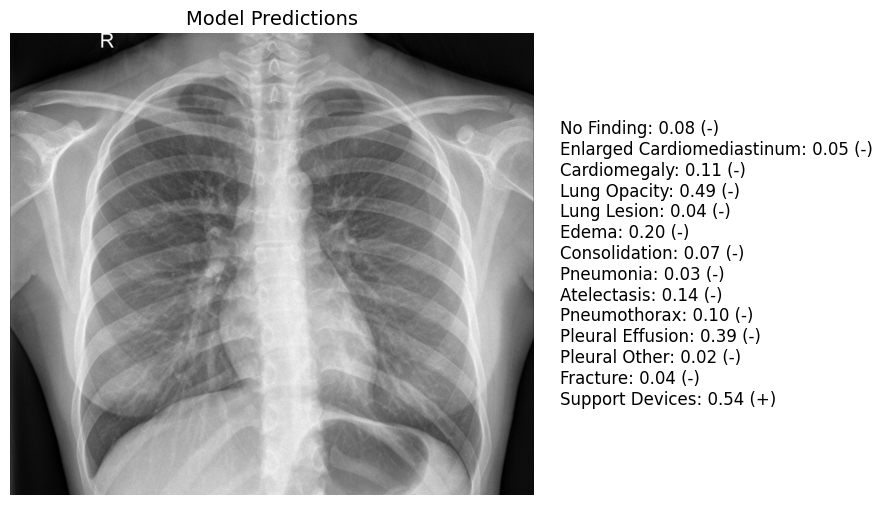

In [20]:
plt.figure(figsize=(8,6))
plt.imshow(image, cmap="gray")
plt.axis("off")

text = "\n".join([
    f"{CHEXPERT_LABELS[i]}: {probs[i]:.2f} ({'+' if probs[i]>=0.5 else '-'})" for i in range(len(CHEXPERT_LABELS))
])

plt.title("Model Predictions", fontsize=14)
plt.text(1.05, 0.5, text, transform=plt.gca().transAxes, fontsize=12, verticalalignment="center")

plt.show()